### To make a complete system, first we make them in ipynb and later make corresponding python .py files for each

#### AI Tutor is a multi-agent agentic system that follows multi-agent architecture.

##### We add multiple specialized agents to the AI Tutor that works autonomouly parallely or sequentially based upon the requirements to reach/achieve the goal. Supervisor being at the top makes the goal into sub-goals and provide the sub-goal to corresponding agents based upon the specialization

##### All the necessary imports are:

In [ ]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Optional, List, Annotated
from langchain_ollama import OllamaEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage, BaseMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS, Chroma
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from sklearn.metrics.pairwise import cosine_similarity
from langgraph.graph.message import add_messages
from langgraph.types import Command, Interrupt
from dotenv import load_dotenv
import os
import operator

In [ ]:
load_dotenv()

### Supervisor and Workers:- 

##### We need to make a supervisor agent where all the workers agent that are going to work and their use are given to the supervisor using prompt so that it can make reasoning and then handsoff the corresponding agent.

##### The supervisor should route the task to the corresponding agent in such a way that the whole task could be done by the agent in and no other agent's capable work should be given to the agent. Such prompt should be given to the supervisor agent.

##### Each agent will get the task that only belongs to it and then when the agent does its work then the agent will change the state due to which the supervisor can get all the changes done by the agent and go for the next job to delegate.

##### It's just like the Orchestrator.

### tools

In [ ]:
llm = ChatGroq(
    api_key=os.getenv("api_key"),
        model="llama-3.3-70b-versatile"
)

embedding_model = OllamaEmbeddings(model="llama3.2")

# llm = ChatNVIDIA(
#   model="openai/gpt-oss-20b",
#   api_key="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", 
#   temperature=1,
#   top_p=1,
#   max_tokens=4096,
# )


# llm = ChatOllama(model = "llama3.2")

tavily_research_tool = TavilySearch(max_results=3, include_answer= True, search_depth= "advanced", auto_parameters=True)
tavily_research_tool.invoke({"query" : "What is llm?"})

In [ ]:
# making dictionary for each of the agents tool

# research agent
research_tools = [tavily_research_tool]
research_tools_by_name = {tool.name : tool for tool in research_tools}

# task_specific_agent
materials_tools = []
materials_tools_by_name = {tool.name : tool for tool in materials_tools}

#rag_agent
rag_tools = []
rag_tools_by_name = {tool.name : tool for tool in rag_tools}

# youtube_agent
youtube_tools = []
youtube_tools_by_name = {tool.name : tool for tool in youtube_tools}

### LLM for each agents with tools binded to it

In [ ]:
llm = ChatGroq(model= os.getenv("model"), api_key=os.getenv("api_key"))
research_agent_with_tool =  llm.bind_tools([tavily_research_tool])
rag_agent_with_tool = llm.bind_tools(rag_tools)
youtube_agent_with_tool = llm.bind_tools(youtube_tools)
task_agent_with_tool = llm.bind_tools(materials_tools)


#### RAG tool:

#### document loader:

In [ ]:
# for now, just use the file from the folder (no selection)
pdfLoader = PyPDFLoader(file_path="Attention.pdf")
documents = pdfLoader.load()
print("The documents are:")
for i in documents:
    print(i.page_content)
    print("✨"*50)

In [ ]:
# since each of the chunk or the document is large (more uneccessary tokens consumed and more dilution of context)
chunking = RecursiveCharacterTextSplitter(chunk_size = 200, chunk_overlap = 80)
chunks = chunking.split_documents(documents)

processed_chunks = []
for chunk in chunks:
    processed_chunks.append(chunk.page_content)
print(processed_chunks)

In [ ]:
# vector store and retriever 
vectorStore = Chroma.from_documents(
    documents=chunks,
    embedding= embedding_model,
    collection_name = "DB_Store",
)

# retriever
retriever = vectorStore.as_retriever(search_type = "mmr", search_kwargs = {'k' : 2, 'fetch_k' : 5, 'lambda_mult' : 0.7})

In [ ]:
class Output(BaseModel):
    summary : str = Field(description="Contains the summary of the relevant document")

output_schema = PydanticOutputParser(pydantic_object=Output)
# tool for RAG
@tool()
def Retriever(query : str):
    '''Retriever for retrieving relevant documents from user provided document'''
    relevant_documents = retriever.invoke(query)
    page_content = []
    for doc in relevant_documents:
        page_content.append(doc.page_content)
    print(page_content)
    prompt = ChatPromptTemplate.from_messages([
        ('system', """You are a good summarizer that can summarize the relevant documents provided that are extracted from user provided document with the user query\n "
        ****strucutre*** 
         {format}\n
        ****RULES****
         - You are only allowed to use your reasoning knowledge to summarize the relevant documents with the help of qeury
         - Dont go out of the context"""),
        ("human", "Query : {query} \n relevant _documents : {relevant_documents}")
    ]).partial(format = output_schema.get_format_instructions())
    chain = prompt | llm | output_schema
    result = chain.invoke({'query' : query, "relevant_documents" : relevant_documents})
    return result.summary

Retriever.name
Retriever.description
Retriever.args

In [ ]:
ans = Retriever.invoke({'query' : "What is self attention"})
ans

In [ ]:
text1 = "I want to eat something."
text2 = "He is a good actor"
embed1 = embedding_model.embed_query(text1)
embed2 = embedding_model.embed_query(text2)
docs = ["He is a good actor", "I am hungry", "THose were some good times"]
embed3 = embedding_model.embed_documents(docs)
print('text1', embed1)
print('text2', embed2)
print(cosine_similarity([embed1], [embed2]))
print(cosine_similarity([embed1], embed3))

In [ ]:
# BaseModels

class Task(BaseModel):
    '''contains information of each step of the plan'''
    id : int = Field(description="id of the step")
    goal : str = Field(description="goal that the user needs to reach after reding the task's answer")
    tool_required : bool = Field("True if research tool is required and False if not")

task_schema = PydanticOutputParser(pydantic_object=Task)

class Plan(BaseModel):
    '''list of plan'''
    plan : list[Task]

plan_schema = PydanticOutputParser(pydantic_object=Plan)

class Goal(BaseModel):
    '''contains the goal for the particualr agent with name of the agent'''
    # title : str = Field(description = "name or title based upon the user query")
    id : int = Field(description = "id of the agent in integer")
    agent : Literal['Researcher', 'RAG', 'Materials', 'YoutubeAgent', 'END'] = Field(description="one specific agent that is to be choosen for the work")
    sub_goal : str = Field(description = "goal that is provided the to the specific one agent")

sub_goal_schema = PydanticOutputParser(pydantic_object=Goal)

class RAG_agent_type(BaseModel):
    pass


class Youtube_agent_type(BaseModel):
    pass


class StudyStep(BaseModel):
    id : int = Field(description="step of the plan")
    sub_goal : str = Field(description="topic of the step")
    content : str = Field(description="Content of the topic in sub-points")

class StudyPlannerModel(BaseModel):
    roadmap : list[StudyStep] = Field("Contains list of step of the roadmap")

study_step_schema = PydanticOutputParser(pydantic_object=StudyStep)
study_planner_schema = PydanticOutputParser(pydantic_object=StudyPlannerModel)

class QAandFlashCardsModel(BaseModel):
    question : list[str] = Field(description="list of question")
    answer : list[str] = Field(description="list of asnwers")

QA_schema = PydanticOutputParser(pydantic_object=QAandFlashCardsModel)

class MaterialGoal(BaseModel):
    '''contains the goal for the particualr agent with name of the agent'''
    id : int = Field(description = "id of the agent in integer")
    agent : Literal['QAandFlashCards', "StudyPlanner", "END"] = Field(description="one specific agent that is to be choosen for the work")
    sub_goal : str = Field(description = "goal that is provided the to the specific one agent")

material_sub_goal_schema = PydanticOutputParser(pydantic_object=MaterialGoal)

In [185]:
# id and agent_name
mapper = {
    1 : 'Researcher',
    3 : 'Materials',
    5 : 'END'
}

material_mapper = {
    1 : "QAandFlashCards",
    2 : "StudyPlanner",
    3 : "END"
}

# Research Graph
class ResearchState(TypedDict):
    # Sub-goal given by the supervisor
    sub_goal : str
    # plan made by the researcher agent
    agent_plan : Annotated[list[Task], operator.add]
    # explaination done by agent (either toolMessage or the AiMessage)
    agent_explain : Annotated[list[str], operator.add]
    # key points covered by this agent
    key_points : Annotated[list[str], operator.add]


class StudyPlannerState(TypedDict):
    goal : str
    key_points : list[str] = Field(description="contains the key points of the plan of the topic to study made by the studyPlanner")
    content : StudyPlannerModel

class QAandFlashCardsState(TypedDict):
    goal : str
    QAandFlashCards : QAandFlashCardsModel


# MaterialGraph (Q/A_and_flashcards and study planner))
class MaterialsState(TypedDict):
    # sub-goal given by the supervisor(Helper Supervisor)
    agent_ids : Annotated[list[int], operator.add]
    sub_goal : str
    StudyPlanner : StudyPlannerState
    QAandFlashCards : QAandFlashCardsState


class RAGState(TypedDict):
    pass

class YoutubeState(TypedDict):
    pass

# Main State
class State(TypedDict):
    goal : str
    title : str
    need_RAG : bool
    agent_ids : Annotated[list[int], operator.add]
    Researcher : ResearchState
    YoutubeAgent : Youtube_agent_type
    Materials : MaterialsState


In [ ]:
def Planner(state : ResearchState):
    goal = state['sub_goal']
    # prompt = PromptTemplate(template="goal : {sub_goal} \n\n{format}", input_variables=['sub_goal'], partial_variables={"format" : task_schema.get_format_instructions()})
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You as an excellent planner agent that can generate a beautiful productive plan to give to the worker agents to execute on the basis of your plan. Workers agents will explain based on you plan so make the plan good. 
         Total number of steps must be less than 7. \n
         
         ****TOOL USAGE RULE****
            Set "tool_required" = true ONLY if the goal includes ANY time-dependent intent.

            Time-dependent means:
            - current
            - latest
            - recent
            - today
            - now
            - trending
            - live
            - real-time
            - updated information

            If ANY of these appear or are implied → tool_required = true

            Otherwise (theoretical, general, timeless knowledge) → tool_required = false

            You MUST strictly follow this mapping.\n
                    
         ***Structure***
         Just give me list of steps in the following JSON format:\n
        {plan}\n\n
         where each task is in the form of:\n
         {task}"""),
        ("human", "Goal : {goal}")]).partial(plan = plan_schema.get_format_instructions(), task = task_schema.get_format_instructions())
    chain = prompt | llm | plan_schema
    plan = chain.invoke({'goal' : goal}).plan
    print(plan)
    key_points = []
    agent_plan = []
    for step in plan:
        agent_plan.append({
            'id' : step.id,
            'goal' : step.goal,
            'tool_required' : step.tool_required
        })
        key_points.append(step.goal)
    print(agent_plan)
    return {'agent_plan' : agent_plan, 'key_points' : key_points}

In [ ]:
Planner(ResearchState(sub_goal="RNN"))

In [168]:
def Researcher(state : ResearchState):
    plan = state['agent_plan']
    explaination = []
    prompt = ChatPromptTemplate.from_messages([
        ('system', """
    You are a **Research & Explanation Agent**.

    You will receive **one task at a time**. Your job is to produce content that directly satisfies the goal.
    Rules:
    - Focus only on the current task. Do not explain unrelated concepts.
    - Adapt explanation to goal type: definition, math, numeric example, summary, etc.
    - Output concise, relevant explanation. No forced headings, templates, or extra text.
    """),
        ('human', "task : {task}")
    ])
    for step in plan:
        print(step)
        if step['tool_required'] == True:
            # do the llm call with the tool_required
            output = research_agent_with_tool.invoke(step['goal'])
            if not output.tool_calls :
                print("⚠️No tools called despite of the tool_required : TRUE")
                print(output.content)
            else:
                tool_recommended = output.tool_calls[0]
                tool_name = research_tools_by_name[tool_recommended['name']]
                tool_output = tool_name.invoke(tool_recommended['args'])['answer']
                print(tool_output)
                explaination.append(tool_output)
        else:
            chain = prompt | llm | StrOutputParser()
            # result = chain.invoke(step['goal'])
            message = HumanMessage(content=step['goal'])  # wrap goal
            result = chain.invoke([message])            
            print(result)
            explaination.append(result)

    return {'agent_explain' : explaination}

In [ ]:
Researcher({'agent_plan': [{'id': 1,
   'goal': 'Identify current trends in AI',
   'tool_required': True},
  {'id': 2,
   'goal': 'Analyze recent developments in AI research',
   'tool_required': True},
  {'id': 3,
   'goal': 'Explore applications of AI in various industries',
   'tool_required': False},
  {'id': 4,
   'goal': 'Summarize key findings and insights on AI trends',
   'tool_required': False},
  {'id': 5,
   'goal': 'Provide recommendations for future AI research and development',
   'tool_required': False},
  {'id': 6,
   'goal': 'Present the final report on AI trends',
   'tool_required': False}]})

In [ ]:
researchGraph = StateGraph(ResearchState)

researchGraph.add_node("Planner", Planner)
researchGraph.add_node("Researcher", Researcher)

researchGraph.add_edge(START, "Planner")
researchGraph.add_edge("Planner", "Researcher")
researchGraph.add_edge("Researcher", END)

ResearcherSubGraph = researchGraph.compile()
ResearcherSubGraph

In [ ]:
ResearcherSubGraph.invoke({'sub_goal' : "explain self sttention clearly"})

In [173]:
def MiniSuervisor(state : MaterialsState):
    # get the sub-goal from the user and this will chose which agent to route the goal to with what goal.
    sub_goal = state['sub_goal']
    agent_ids = state.get("agent_ids", [])
    print(agent_ids)
    record = {}
    for agent_id in material_mapper:
        if not agent_id in agent_ids:
            record[agent_id] = material_mapper[agent_id]
    prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a Supervisor Agent.

    Your job is to select EXACTLY ONE worker agent to handle the given goal.

    ------------------------
    ALL AGENTS:
    1. QAandFlashCards → Generate Q/A or flashcards
    2. StudyPlanner → Create study roadmap
    3. END → Use ONLY if no valid agent remains
    ------------------------

    ALREADY USED AGENTS:
    {agent_ids}

    AVAILABLE AGENTS (ONLY CHOOSE FROM HERE):
    {record}

    ------------------------
    STRICT RULES:
    - You MUST select ONLY ONE agent from AVAILABLE AGENTS
    - NEVER select an agent that is already used
    - If ALL meaningful agents are already used → select END
    - Do NOT invent new agents
    - Do NOT ignore AVAILABLE AGENTS list
    - Do NOT return anything except valid JSON

    ------------------------
    Decision Logic:
    1. Check if a suitable agent exists in AVAILABLE AGENTS
    2. If yes → choose it
    3. If no → choose END

    ------------------------
    Return format:
    {format}
    """),
    ("human", "goal: {sub_goal}")
]).partial(format=material_sub_goal_schema.get_format_instructions())
    chain = prompt | llm | material_sub_goal_schema
    result = chain.invoke({"record" : record, 'sub_goal' : sub_goal, "agent_ids" : agent_ids})
    # if study and qa/flashcard agent are already then dont add them
    if 1 in agent_ids or 2 in agent_ids:
        print("agent already used")
        print("Material Supervisor ✅")
        return {'agent_ids' : [3]}
    else:
        print("Material Supervisor ✅")
        return {'agent_ids' : [result.id], result.agent : {'goal' : result.sub_goal}}


def StudyPlanner(state : MaterialsState):
    print("StudyPlanner reached✅")
    sub_goal = state.get("StudyPlanner", {}).get("goal", "")
    print(sub_goal)
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert in planning a study roadmap in various topics. You will get a goal and you have to generate a roadmap that is helpful.\n
         ****Rules****"
         - You will generate a roadmap from basic to advance or course based roadmap targetting beginners and intermediate if not mentioned in goal.
         - You will generate a answer in given format and the content should contain multiple points not like topic with sub-topics.\n
         ****Format****
         - plan : {plan} (list of steps)
         - step : {step} (format of step)
         """),
        ("human", "goal : {sub_goal}")
    ]).partial(step = study_step_schema.get_format_instructions(), plan = study_planner_schema.get_format_instructions())
    chain = prompt | llm | study_planner_schema
    result = chain.invoke({'sub_goal' : sub_goal}).roadmap
    key_points = []
    plan = []
    for step in result:
        key_points.append(step.sub_goal)
        plan.append({
            'id' : step.id,
            'sub_goal' : step.sub_goal,
            'content' : step.content 
        })

    study_planner_state : StudyPlannerState= {
        'goal' : sub_goal, 
        'key_points' : key_points,
        'content' : {
            'roadmap' : plan
        }
    }
    print(study_planner_state)
    print("Study Planner ✅")
    return {"StudyPlanner" : study_planner_state}


def QAandFlashCards(state : MaterialsState):
    sub_goal = state.get("QAandFlashCards", {}).get("goal", "")
    prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a educational researcher agent that can make "
    "1.Question Answer and "
    "2.flashcards "
    "but only one of the two can be used"
    "You will get a goal and u have to analyze the goal and decide whether to produce interview based question / answer, exam style question answer etc or the study helper flashcard"
    "****Format*****"
    "{qa}"
    "****RULE****"
    "for flashcards there should be one or two word answer max"),
    ("human", "goal : {goal}")
    ]).partial(qa = QA_schema.get_format_instructions())
    chain = prompt | llm | QA_schema
    result = chain.invoke({'goal' : sub_goal})
    print(result)
    print("QA and Flashcards ✅")
    data = {
            'goal' : sub_goal,
            'QAandFlashCards' : {
                'question' : result.question,
                'answer' : result.answer
            }
    }
    return {'QAandFlashCards' : data}
    
def SubAgentSelection(state : MaterialsState):
    # print(state.get('agent_ids', []))
    agent_id = state['agent_ids'][-1]
    print("Agents that are used are: ", agent_id)
    print("next agent--->", material_mapper[agent_id])
    print("Routing completed Supervisor ✅")
    if agent_id == 1:
        return "QAandFlashCards"
    
    elif agent_id == 2:
        return "StudyPlanner"
    
    else:
        return "END"

In [ ]:
StudyPlanner(MaterialsState(StudyPlanner={'goal' : 'Create a study roadmap to learn Machine Learning'}))

In [ ]:
QAandFlashCards(MaterialsState(QAandFlashCards={'goal' : "make me a q/a for ml interview"}))

In [ ]:
res = MiniSuervisor(MaterialsState(sub_goal="Make me a roadmap to learn ML"))
res


In [ ]:
subGraph = StateGraph(MaterialsState)
subGraph.add_node("MiniSupervisor", MiniSuervisor)
subGraph.add_node("StudyPlanner", StudyPlanner)
subGraph.add_node("QAandFlashCards", QAandFlashCards)

subGraph.add_edge(START, "MiniSupervisor")
subGraph.add_conditional_edges("MiniSupervisor", SubAgentSelection,{"QAandFlashCards" : "QAandFlashCards", "StudyPlanner" : "StudyPlanner", "END" : END})
subGraph.add_edge("QAandFlashCards", "MiniSupervisor")
subGraph.add_edge("StudyPlanner", "MiniSupervisor")

subSystem = subGraph.compile()

subSystem

In [ ]:
subSystem.invoke({'sub_goal' : "I am going to give exam on ML and that is mcq question so make me a certain question on ml for match the following"})

In [186]:
# FOR THE SUPERVISOR NODE
def Supervisor(state : State):
    goal = state['goal']
    researcher = state.get('Researcher', {}).get("key_points", [])
    task_specific = state.get('Materials', {}).get("sub_goal", [])
    agent_ids = state.get('agent_ids', [])
    record = {}
    for agent_id in mapper:
        if agent_id in agent_ids:
            record[mapper[agent_id]] = "occupied"
        else:
            record[mapper[agent_id]] = "free"

    print(record)
    print("Already used agents :", agent_ids)
    print(goal)
    print(researcher)
    prompt = ChatPromptTemplate([
        ('system', 
         """You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents\n

         ****Specialized agents(worker agents) id and their speciality****
         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)
         3 --> Materials : Task Specific works like if have to make a roadmap or interview/academic/practice type question answers or study helping flashcards
         5 --> END : If no any agents is required now.\n\n
        
         Now, you can get a goal that may require multiple agents to achieve the goal, so only provide the goal the agent is made for. You have to choose one of the above agents based upon the user query and agent specialization/use. \n\n

         ****Specialized agents(worker agents) name and their work till now*****
         Researcher : {researcher_work}
         Materials : {task_specific_work}
         
         Very important Note : If there is [] with no elements in any of the agent, that means the agent hasn't been used yet. \n\n
         
         ****Agents state****
         {record}

         "free" can be used again
         "occupied" are not accessible
         ****Structure****
    
         To provide the specific agent you have to return the goal in the following structure\n

         {format}\n\n

        ****Rules****
         
         - Don't use already used agents
         - Only provide goal to the specialized agent goal when the query seems to demand.
         - Depending upon the user query, its meaning(as you are Tutor) and work done by workers till now, you must call only the required agent at a time,
         - Dont use the used agent twice.

         """),
        ('human', "Goal/Query from user : {goal}")
    ]).partial(format = sub_goal_schema.get_format_instructions(), researcher_work  = researcher, task_specific_work = task_specific, record = record)
    print("⚠️"*50)
    print(prompt.invoke({'goal' : goal}))
    print("⚠️"*50)
    # Generate the title for it
    chain = prompt | llm | sub_goal_schema
    response = chain.invoke({'goal' : goal})
    print(type(response.id))
    print("next agent ---> ", response.id)
    print('Supervisor Completed ✅')
    return {'agent_ids' : [response.id], response.agent : {'sub_goal' : response.sub_goal}}

In [187]:
Supervisor(State(goal="make me a road map to learn self-attention"))

{'Researcher': 'free', 'Materials': 'free', 'END': 'free'}
Already used agents : []
make me a road map to learn self-attention
[]
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
messages=[SystemMessage(content='You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents\n\n\n         ****Specialized agents(worker agents) id and their speciality****\n         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)\n         3 --> Materials : Task Specific works like if have to make a roadmap or interview/academic/practice type question answers or study helping flashcards\n         5 --> END : If no any agents is required now.\n\n\n\n         Now, you can get a goal that may require multiple agents to achieve the goal, so only provide the goal the agent is made for. You have to choose one of the above agents based upon the user query and agent specialization/use. \n\

{'agent_ids': [3],
 'Materials': {'sub_goal': 'Create a roadmap to learn self-attention'}}

In [183]:
# FOR THE RESEARCH NODE
# it should be complex as its job is not only to extract one knowledge but many aspects like what, how, why, when, exmaples, mechanism etc.
def Researcher(state : State):
    sub_goal = state['Researcher']['sub_goal']
    print("Researcher agent's Goal: ",sub_goal)
    response = ResearcherSubGraph.invoke({'sub_goal' : sub_goal})
    print(response)
    print('Research Completed ✅')
    return {'Researcher' : {
        'sub_goal' : response['sub_goal'],
        'agent_plan' : response['agent_plan'],
        'agent_explain' : response['agent_explain'],
        'key_points' : response['key_points']
    }}

In [ ]:
Researcher(State(Researcher= {
    'sub_goal' : "Self Attention",
}))

In [ ]:
def YoutubeVideos(state : State):
    pass

In [188]:
# FOR THE YOUTUBEVIDEOS NODE
def Materials(state : State):
    # task provided by the main supervisor
    sub_goal = state.get('Materials', {}).get("sub_goal", [])
    print("goal provided by the supervisor", sub_goal)
    output = subSystem.invoke({'sub_goal' : sub_goal})
    print(output)
    return {
        'Materials' : {
            'agent_ids' : output['agent_ids'],
            "sub_goal" : output['sub_goal'],
            'StudyPlanner' : output.get("StudyPlanner", {}),
            "QAandFlashCards" : output.get("QAandFlashCards", {})
        }
    }
    # output will be in the structure of MaterialState

# agent_ids : Annotated[list[int], operator.add]
# sub_goal : str
# StudyPlanner : StudyPlannerState
# QAandFlashCards : QAandFlashCardsState

In [190]:
Materials(State(Materials={'sub_goal' : "help me start to learn AI for making projects"}))

goal provided by the supervisor help me start to learn AI for making projects
[]
Material Supervisor ✅
Agents that are used are:  2
next agent---> StudyPlanner
Routing completed Supervisor ✅
StudyPlanner reached✅
create a study roadmap for learning AI to make projects
{'goal': 'create a study roadmap for learning AI to make projects', 'key_points': ['Mathematics and Statistics Fundamentals', 'Programming Skills', 'Introduction to AI and Machine Learning', 'Machine Learning Fundamentals', 'Deep Learning', 'Natural Language Processing (NLP)', 'Computer Vision', 'Project Development', 'Model Deployment'], 'content': {'roadmap': [{'id': 1, 'sub_goal': 'Mathematics and Statistics Fundamentals', 'content': " \n        - Linear Algebra: vectors, matrices, operations, and applications\n        - Calculus: probability, statistics, and optimization techniques\n        - Probability and Statistics: probability distributions, Bayes' theorem, and statistical inference\n        - Python libraries: N

{'Materials': {'agent_ids': [2, 3],
  'sub_goal': 'help me start to learn AI for making projects',
  'StudyPlanner': {'goal': 'create a study roadmap for learning AI to make projects',
   'key_points': ['Mathematics and Statistics Fundamentals',
    'Programming Skills',
    'Introduction to AI and Machine Learning',
    'Machine Learning Fundamentals',
    'Deep Learning',
    'Natural Language Processing (NLP)',
    'Computer Vision',
    'Project Development',
    'Model Deployment'],
   'content': {'roadmap': [{'id': 1,
      'sub_goal': 'Mathematics and Statistics Fundamentals',
      'content': " \n        - Linear Algebra: vectors, matrices, operations, and applications\n        - Calculus: probability, statistics, and optimization techniques\n        - Probability and Statistics: probability distributions, Bayes' theorem, and statistical inference\n        - Python libraries: NumPy, SciPy, and Pandas for mathematical computations\n      "},
     {'id': 2,
      'sub_goal': 'Pro

In [ ]:
# FOR THE RAG AGENT
def RAG(state : State):
    # we have retriever that is used to retrieve the corresponding queries asnwer from the document
    pass

In [ ]:
# at the end when all the task are completed then all the results from each agent are synthesized into proper format
def Synthesizer(state : State):
    print("Synthesizer ✅")

    return {}
    # At last synthesize the whole blog/goal that are broken down and submitted to all the agents into one single organized form

In [155]:
def AgentSelection(state : State):
    print("AGENT IDS", state.get("agent_ids"), [])
    agent_id = state['agent_ids'][-1]
    print("agent id",type(agent_id))
    print("next ---->", agent_id)
    if agent_id == 1:
        return "Researcher"
    elif agent_id == 2: 
        return "RAG"
    elif agent_id == 3:
        return "Materials"
    elif agent_id == 4:
        return "YoutubeAgent"
    else:
        return "Synthesizer"

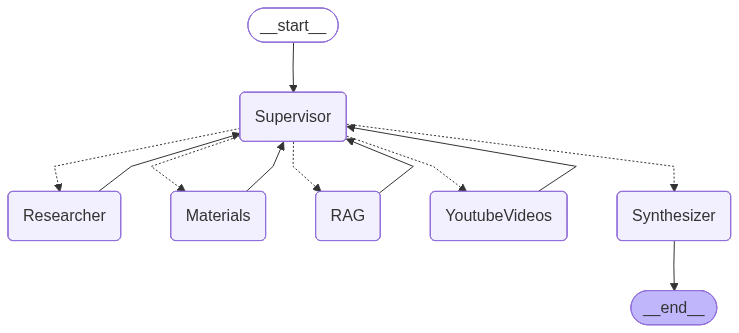

In [191]:
graph = StateGraph(State)
graph.add_node("Supervisor", Supervisor)
graph.add_node("Researcher", Researcher)
graph.add_node("Materials", Materials)    
graph.add_node("RAG", RAG)
graph.add_node("YoutubeVideos", YoutubeVideos)
graph.add_node("Synthesizer", Synthesizer)

graph.add_edge(START, "Supervisor")
graph.add_conditional_edges("Supervisor", AgentSelection, {"Researcher" : "Researcher", "RAG" : "RAG", "YoutubeVideos" : "YoutubeVideos", "Materials" : "Materials", "Synthesizer" : "Synthesizer"})
graph.add_edge("Researcher", "Supervisor")
graph.add_edge("RAG", "Supervisor")
graph.add_edge("Materials", "Supervisor")
graph.add_edge("YoutubeVideos", "Supervisor")
graph.add_edge("Synthesizer", END)

MainGraph = graph.compile()

MainGraph



In [192]:
MainGraph.invoke({'goal' : "explain Self-Attention and make me a road map to learn it"})

{'Researcher': 'free', 'Materials': 'free', 'END': 'free'}
Already used agents : []
explain Self-Attention and make me a road map to learn it
[]
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
messages=[SystemMessage(content='You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents\n\n\n         ****Specialized agents(worker agents) id and their speciality****\n         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)\n         3 --> Materials : Task Specific works like if have to make a roadmap or interview/academic/practice type question answers or study helping flashcards\n         5 --> END : If no any agents is required now.\n\n\n\n         Now, you can get a goal that may require multiple agents to achieve the goal, so only provide the goal the agent is made for. You have to choose one of the above agents based upon the user query and agent speciali

{'goal': 'explain Self-Attention and make me a road map to learn it',
 'agent_ids': [1, 3, 5],
 'Researcher': {'sub_goal': 'Research and explain the concept of Self-Attention.',
  'agent_plan': [{'id': 1,
    'goal': 'Understand the basics of Self-Attention',
    'tool_required': False},
   {'id': 2,
    'goal': 'Research the concept of Self-Attention in deep learning',
    'tool_required': True},
   {'id': 3,
    'goal': 'Explain the architecture and components of Self-Attention',
    'tool_required': False},
   {'id': 4,
    'goal': 'Provide examples and applications of Self-Attention in NLP and other fields',
    'tool_required': False},
   {'id': 5,
    'goal': 'Summarize the key points and benefits of Self-Attention',
    'tool_required': False}],
  'agent_explain': ['Self-Attention is a mechanism used in deep learning, particularly in natural language processing (NLP) and computer vision. It\'s a key component of Transformer models.\n\n**What is Self-Attention?**\n\nSelf-Attentio